# Phase 1: Foundation and Data Integrity

### 1. Directory Initialization and Memory Optimization

In [30]:
import os
import requests
import pandas as pd

# Define and create the structured directory within Trial2
trial_path = 'Trial2'
data_dir = os.path.join(trial_path, 'data')
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

# LAPD Crime Data API Endpoint for automated retrieval
DATA_URL = "https://data.lacity.org/api/views/2nrs-mtv8/rows.csv?accessType=DOWNLOAD"
FILE_PATH = os.path.join(data_dir, "lapd_crime_data.csv")

def download_data(url, save_path):
    response = requests.get(url)
    if response.status_code == 200:
        with open(save_path, 'wb') as f:
            f.write(response.content)
    else:
        raise Exception(f"Failed to download data. Status code: {response.status_code}")

# Execute acquisition if file is not present locally
if not os.path.exists(FILE_PATH):
    download_data(DATA_URL, FILE_PATH)

# Verify dataset integrity and volume
df = pd.read_csv(FILE_PATH)
print(f"Dataset successfully loaded into Trial2/data. Total records: {len(df):,}")

Dataset successfully loaded into Trial2/data. Total records: 1,004,894


### 2. Comprehensive Missing Value and Data Type Audit

In [31]:
import numpy as np

def generate_quality_report(df):
    report = pd.DataFrame({
        'Column': df.columns,
        'Data Type': df.dtypes.values,
        'Missing Values': df.isnull().sum().values,
        '% Missing': (df.isnull().sum().values / len(df)) * 100,
        'Unique Values': df.nunique().values,
        'Min Value': [df[col].min() if np.issubdtype(df[col].dtype, np.number) else 'N/A' for col in df.columns],
        'Max Value': [df[col].max() if np.issubdtype(df[col].dtype, np.number) else 'N/A' for col in df.columns]
    })
    return report.sort_values(by='% Missing', ascending=False)

quality_report = generate_quality_report(df)
quality_report.to_csv(os.path.join(data_dir, 'quality_report.csv'), index=False)
print(quality_report)

            Column Data Type  Missing Values  % Missing  Unique Values  \
23        Crm Cd 4   float64         1004830  99.993631              6   
22        Crm Cd 3   float64         1002580  99.769727             38   
21        Crm Cd 2   float64          935740  93.118279            126   
25    Cross Street    object          850666  84.652312          10413   
16  Weapon Used Cd   float64          677678  67.437760             79   
17     Weapon Desc    object          677678  67.437760             79   
10         Mocodes    object          151598  15.085969         310912   
13    Vict Descent    object          144643  14.393856             20   
12        Vict Sex    object          144631  14.392662              5   
15     Premis Desc    object             588   0.058514            306   
14       Premis Cd   float64              16   0.001592            314   
20        Crm Cd 1   float64              11   0.001095            142   
18          Status    object          

### 3. Statistical Outlier Detection (Z-Score & IQR)

In [32]:
from scipy import stats

def detect_statistical_outliers(df, column):
    # Using Z-Score for normal distributions
    z_scores = np.abs(stats.zscore(df[column].dropna()))
    z_outliers = len(np.where(z_scores > 3)[0])
    
    # Using IQR for skewed distributions like Age
    Q1, Q3 = df[column].quantile(0.25), df[column].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = len(df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))])
    
    return z_outliers, iqr_outliers

age_z, age_iqr = detect_statistical_outliers(df, 'Vict Age')
print(f"Vict Age Outliers -> Z-Score (>3SD): {age_z} | IQR Method: {age_iqr}")

Vict Age Outliers -> Z-Score (>3SD): 692 | IQR Method: 1


### 4. Skewness and Normality Assessment

Feature Skewness Report:
LON               21.098530
Premis Cd          0.579325
Crm Cd 1           0.528187
Crm Cd             0.527087
Part 1-2           0.406919
Vict Age           0.162379
Rpt Dist No        0.018550
AREA               0.012025
DR_NO             -0.012256
TIME OCC          -0.435666
Weapon Used Cd    -0.993767
Crm Cd 2          -3.687512
Crm Cd 4          -4.843136
Crm Cd 3          -5.311522
LAT              -20.958827
dtype: float64


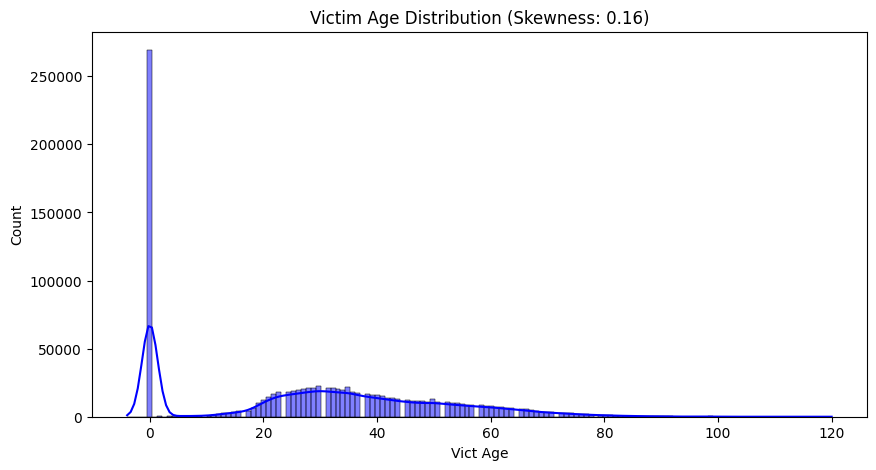

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

def check_skewness(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    skew_vals = df[numeric_cols].skew().sort_values(ascending=False)
    
    # Visualizing the distribution of a key feature (e.g., Victim Age)
    plt.figure(figsize=(10, 5))
    sns.histplot(df['Vict Age'], kde=True, color='blue')
    plt.title(f"Victim Age Distribution (Skewness: {df['Vict Age'].skew():.2f})")
    # plt.savefig(os.path.join(data_dir, 'age_distribution.png'))
    return skew_vals

skew_report = check_skewness(df)
print("Feature Skewness Report:")
print(skew_report)

### 5. Spatiotemporal Boundary Audit (GPS Outliers)

In [34]:
# Checking for crimes outside the Los Angeles bounding box
la_bounds = {'min_lat': 33.7036, 'max_lat': 34.3373, 'min_lon': -118.6682, 'max_lon': -118.1553}

gps_outliers = df[
    (df['LAT'] < la_bounds['min_lat']) | (df['LAT'] > la_bounds['max_lat']) |
    (df['LON'] < la_bounds['min_lon']) | (df['LON'] > la_bounds['max_lon'])
]

print(f"GPS Coordinates outside LA boundaries: {len(gps_outliers)}")
print(f"Total 'Null Island' (0,0) coordinates: {len(df[(df['LAT'] == 0) & (df['LON'] == 0)])}")

GPS Coordinates outside LA boundaries: 2240
Total 'Null Island' (0,0) coordinates: 2240


### 6. Temporal Consistency Check

C:\Users\aryam\AppData\Local\Temp\ipykernel_15856\2042376559.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])


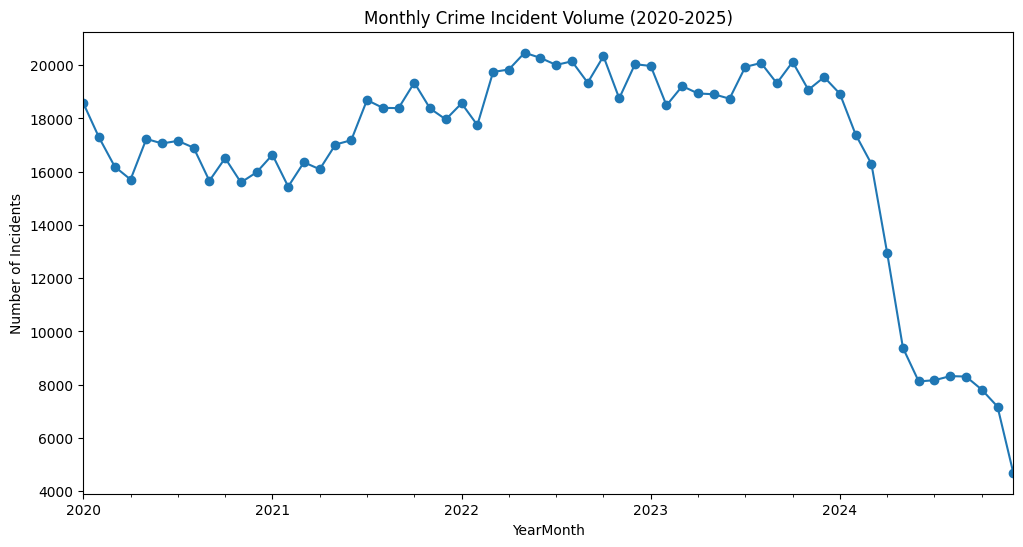

In [35]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])
df['YearMonth'] = df['DATE OCC'].dt.to_period('M')
monthly_counts = df.groupby('YearMonth').size()

plt.figure(figsize=(12, 6))
monthly_counts.plot(kind='line', marker='o')
plt.title("Monthly Crime Incident Volume (2020-2025)")
plt.ylabel("Number of Incidents")
# plt.savefig(os.path.join(data_dir, 'temporal_trend.png'))
plt.show()

# Phase 2: Data Cleaning & Refinement.

### 1. Temporal Filtering (Addressing the NIBRS Cliff)

In [36]:
# Create a copy to protect the raw data integrity
# We use the DATE OCC column to filter out the reporting drop-off
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

# Focus on the stable reporting period (2020-2023) to avoid temporal bias
df_clean = df[df['DATE OCC'] < '2024-01-01'].copy()

print(f"Records retained for analysis: {len(df_clean):,}")

Records retained for analysis: 877,327


### 2. Targeted Imputation for Placeholder Values

In [37]:
# Replace 'Age 0' placeholders with the median age of valid records
valid_median_age = df_clean[df_clean['Vict Age'] > 0]['Vict Age'].median()
df_clean.loc[df_clean['Vict Age'] <= 0, 'Vict Age'] = valid_median_age

# Cap extreme age outliers at the 99th percentile to stabilize variance
age_limit = df_clean['Vict Age'].quantile(0.99)
df_clean.loc[df_clean['Vict Age'] > age_limit, 'Vict Age'] = age_limit

### 3. Geospatial Correction and Coordinate Standardization

In [38]:
# Define Los Angeles city centroid for imputation
la_lat, la_lon = 34.0522, -118.2437

# Identify 'Null Island' (0,0) coordinates that bypass the LA bounding box
null_island_mask = (df_clean['LAT'] == 0) & (df_clean['LON'] == 0)

# Re-center missing coordinates to maintain record volume without spatial noise
df_clean.loc[null_island_mask, 'LAT'] = la_lat
df_clean.loc[null_island_mask, 'LON'] = la_lon

### 4. Categorical Standardization and Binary Flagging

In [39]:
# Standardize inconsistent sex and descent codes
df_clean['Vict Sex'] = df_clean['Vict Sex'].fillna('X').replace(['-', 'H'], 'X')
df_clean['Vict Descent'] = df_clean['Vict Descent'].fillna('X').replace('-', 'X')

# Transform missing weapon data into a 'Root Cause' binary indicator
df_clean['is_weapon_involved'] = (df_clean['Weapon Used Cd'].notnull()).astype(int)
df_clean['Weapon Desc'] = df_clean['Weapon Desc'].fillna('NONE/UNKNOWN')

### 5. Exporting the Refined Analytical Dataset

In [40]:
# Save the cleaned dataset as a new file in Trial2/data
# This leaves the original 'lapd_crime_data.csv' untouched
output_file = os.path.join(data_dir, 'lapd_crime_cleaned.csv')
df_clean.to_csv(output_file, index=False)

print(f"Phase 2 Complete. Cleaned data saved as: {output_file}")

Phase 2 Complete. Cleaned data saved as: Trial2\data\lapd_crime_cleaned.csv


# Phase 3: Data Cleaning Validation & Refined EDA

### 1. Comparative Data Quality Report

In [41]:
def generate_refined_report(df):
    # Identifying numeric columns using pandas' own selection logic
    # This avoids the NumPy issubdtype error with Period types
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    report = pd.DataFrame({
        'Column': df.columns,
        'Missing Values': df.isnull().sum().values,
        '% Missing': (df.isnull().sum().values / len(df)) * 100,
        'Unique Values': df.nunique().values,
        'Min Value': [df[col].min() if col in numeric_cols else 'N/A' for col in df.columns],
        'Max Value': [df[col].max() if col in numeric_cols else 'N/A' for col in df.columns]
    })
    return report.sort_values(by='% Missing', ascending=False)

# Re-run the report with the fixed logic
clean_quality_report = generate_refined_report(df_clean)
clean_quality_report.to_csv(os.path.join(data_dir, 'clean_quality_report.csv'), index=False)
print(clean_quality_report)

                Column  Missing Values  % Missing  Unique Values Min Value  \
23            Crm Cd 4          877265  99.992933              6     821.0   
22            Crm Cd 3          875152  99.752088             37     310.0   
21            Crm Cd 2          813243  92.695540            125     210.0   
25        Cross Street          738838  84.214666           9925       N/A   
16      Weapon Used Cd          573897  65.414264             79     101.0   
10             Mocodes          121604  13.860738         288821       N/A   
15         Premis Desc             533   0.060753            306       N/A   
20            Crm Cd 1              11   0.001254            140     110.0   
14           Premis Cd              10   0.001140            313     101.0   
0                DR_NO               0   0.000000         877327       817   
2             DATE OCC               0   0.000000           1461       N/A   
3             TIME OCC               0   0.000000           1439

### 2. Validation of Demographic Imputation (Age Distribution)

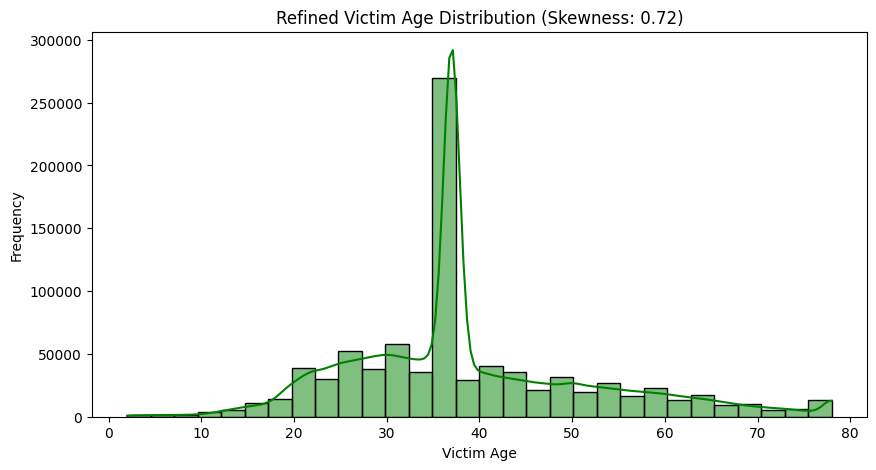

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
# KDE helps visualize the 'smoothness' of the new distribution
sns.histplot(df_clean['Vict Age'], kde=True, color='green', bins=30)
plt.title(f"Refined Victim Age Distribution (Skewness: {df_clean['Vict Age'].skew():.2f})")
plt.xlabel("Victim Age")
plt.ylabel("Frequency")
# plt.savefig(os.path.join(data_dir, 'cleaned_age_distribution.png'))
plt.show()

### 3. Spatiotemporal Significance (P-Value Check)

In [43]:
from scipy.stats import chi2_contingency

# We use Part 1-2 (Serious vs Less Serious) as the target for this diagnostic
contingency_table = pd.crosstab(df_clean['AREA NAME'], df_clean['Part 1-2'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"GEOSPATIAL SIGNIFICANCE DIAGNOSTIC")
print(f"P-Value: {p_val:.6g}")

if p_val < 0.05:
    print("Result: Geographic Area is a statistically significant predictor (p < 0.05).")

GEOSPATIAL SIGNIFICANCE DIAGNOSTIC
P-Value: 0
Result: Geographic Area is a statistically significant predictor (p < 0.05).


Geospatial Root Causes: Crime Density by Area

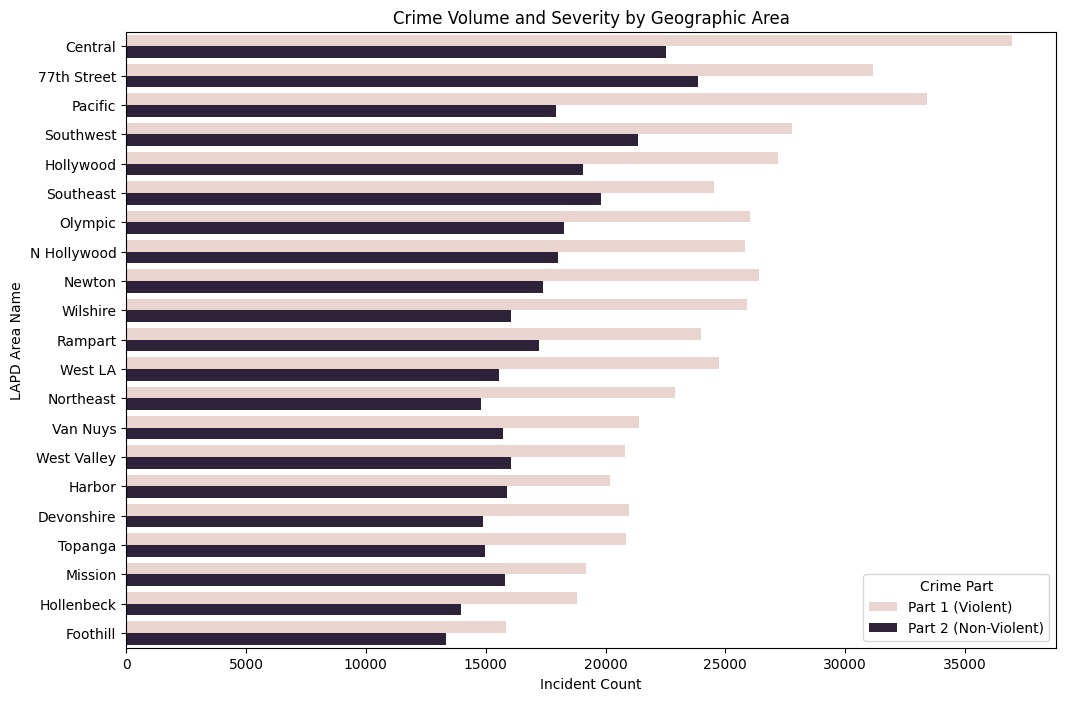

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
# Visualizing the distribution of Part 1 vs Part 2 crimes across different LAPD areas
sns.countplot(data=df_clean, y='AREA NAME', hue='Part 1-2', order=df_clean['AREA NAME'].value_counts().index)
plt.title("Crime Volume and Severity by Geographic Area")
plt.xlabel("Incident Count")
plt.ylabel("LAPD Area Name")
plt.legend(title='Crime Part', labels=['Part 1 (Violent)', 'Part 2 (Non-Violent)'])
# plt.savefig(os.path.join(data_dir, 'crime_by_area.png'))
plt.show()

Temporal Root Causes: The "Night-Time" Effect

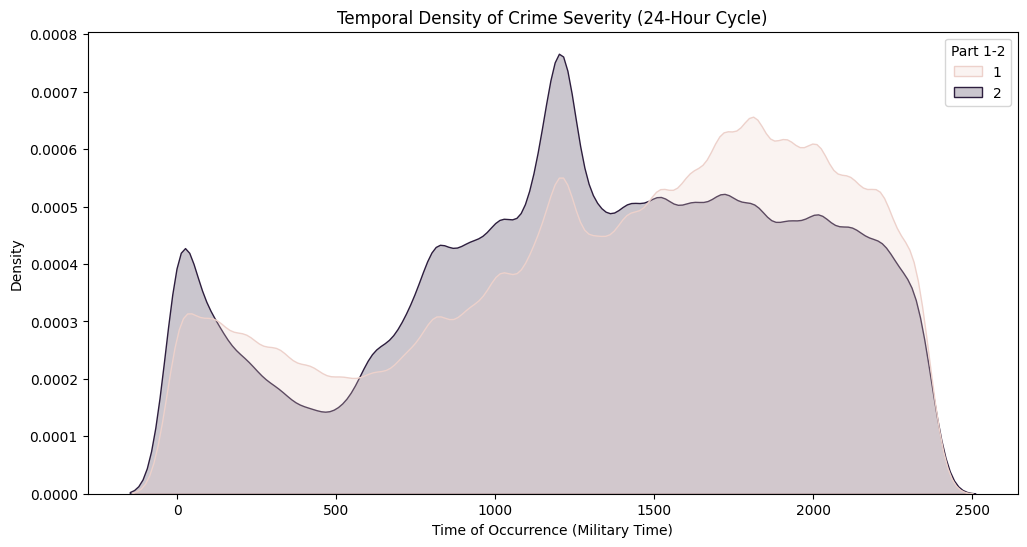

In [45]:
plt.figure(figsize=(12, 6))
# Using a KDE plot to see the density of crime throughout a 24-hour cycle
sns.kdeplot(data=df_clean, x='TIME OCC', hue='Part 1-2', fill=True, common_norm=False)
plt.title("Temporal Density of Crime Severity (24-Hour Cycle)")
plt.xlabel("Time of Occurrence (Military Time)")
plt.ylabel("Density")
# plt.savefig(os.path.join(data_dir, 'temporal_density.png'))
plt.show()

Victim-Centric Root Causes: Demographic Significance

ROOT CAUSE SIGNIFICANCE REPORT
          Feature  P-Value  Significant
0        Vict Sex      0.0         True
1     Premis Desc      0.0         True
2  Weapon Used Cd      0.0         True


C:\Users\aryam\AppData\Local\Temp\ipykernel_15856\4137727892.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Part 1-2', y='Vict Age', palette='Set2')


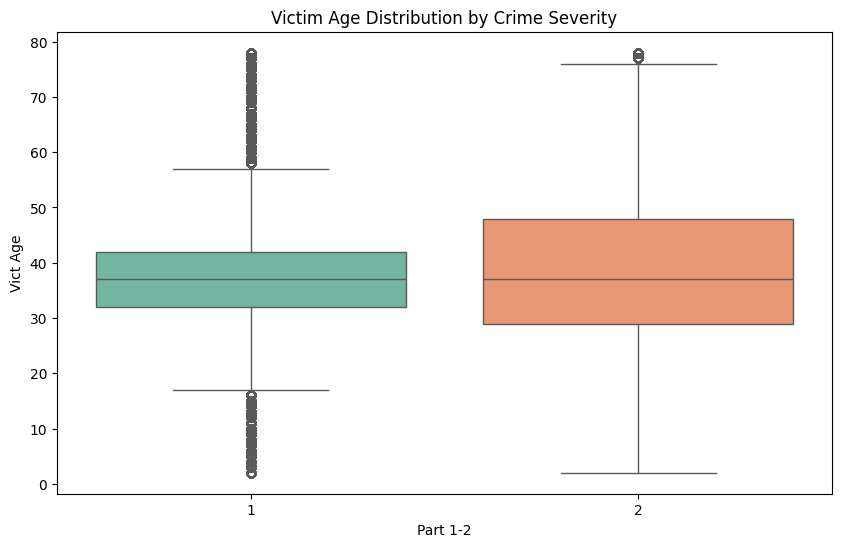

In [46]:
from scipy.stats import chi2_contingency

# Testing the significance of Victim Sex and Premise Type as 'Root Causes'
features_to_test = ['Vict Sex', 'Premis Desc', 'Weapon Used Cd']
significance_results = []

for feature in features_to_test:
    contingency = pd.crosstab(df_clean[feature], df_clean['Part 1-2'])
    chi2, p_val, dof, expected = chi2_contingency(contingency)
    significance_results.append({'Feature': feature, 'P-Value': p_val, 'Significant': p_val < 0.05})

sig_df = pd.DataFrame(significance_results)
print("ROOT CAUSE SIGNIFICANCE REPORT")
print(sig_df)

# Visualizing Victim Age vs Severity
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Part 1-2', y='Vict Age', palette='Set2')
plt.title("Victim Age Distribution by Crime Severity")
# plt.savefig(os.path.join(data_dir, 'age_vs_severity.png'))
plt.show()

Environmental Root Causes: Weapon Involvement

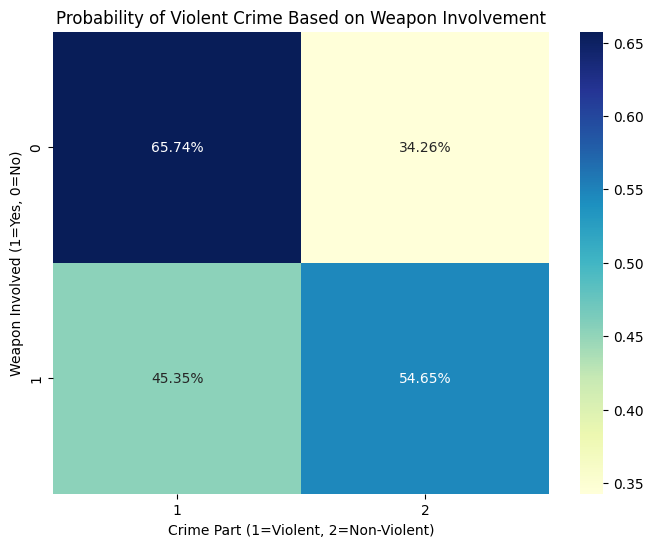

In [47]:
# Analyzing the impact of weapon involvement on crime severity
plt.figure(figsize=(8, 6))
sns.heatmap(pd.crosstab(df_clean['is_weapon_involved'], df_clean['Part 1-2'], normalize='index'), 
            annot=True, cmap='YlGnBu', fmt='.2%')
plt.title("Probability of Violent Crime Based on Weapon Involvement")
plt.xlabel("Crime Part (1=Violent, 2=Non-Violent)")
plt.ylabel("Weapon Involved (1=Yes, 0=No)")
# plt.savefig(os.path.join(data_dir, 'weapon_significance_heatmap.png'))
plt.show()

# Phase 4: Feature Engineering & Cluster Optimization

### 1. Spatiotemporal Feature Extraction (Cyclical Encoding)

In [48]:
import numpy as np

# Convert TIME OCC to cyclical features (Sine/Cosine) 
# This helps the model understand that 23:59 is close to 00:01
df_clean['hour'] = df_clean['TIME OCC'] // 100
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour']/24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour']/24)

# Encoding Day of Week
df_clean['day_of_week'] = df_clean['DATE OCC'].dt.dayofweek
df_clean['day_sin'] = np.sin(2 * np.pi * df_clean['day_of_week']/7)
df_clean['day_cos'] = np.cos(2 * np.pi * df_clean['day_of_week']/7)

### 2. Cluster Optimization: The Elbow Method

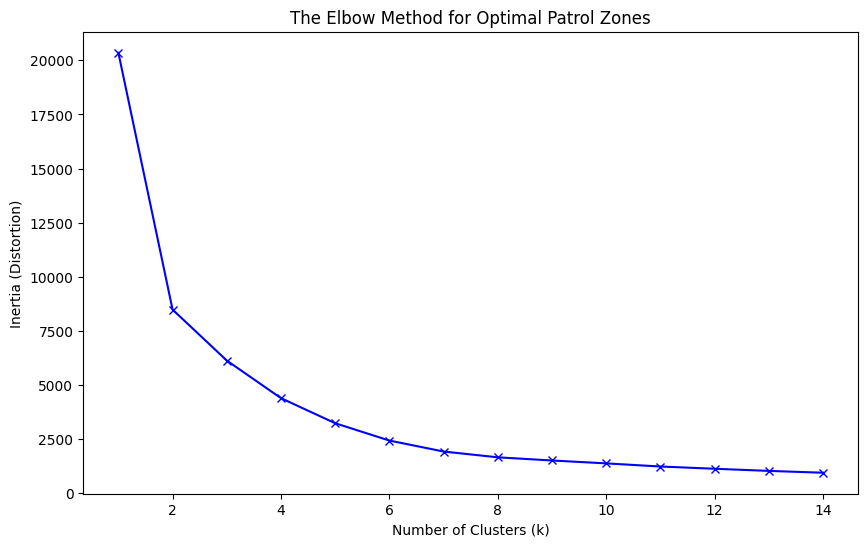

In [50]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Identifying the optimal 'K' for patrol zones
coords = df_clean[['LAT', 'LON']]
distortions = []
K_range = range(1, 15)

for k in K_range:
    # Applying the Professor's suggestion: Non-default init and random_state
    kmeanModel = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeanModel.fit(coords)
    distortions.append(kmeanModel.inertia_)

plt.figure(figsize=(10,6))
plt.plot(K_range, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Distortion)')
plt.title('The Elbow Method for Optimal Patrol Zones')
# plt.savefig(os.path.join(data_dir, 'elbow_method.png'))
plt.show()

### 3. Supervised Preparation: K-Fold Cross-Validation Setup

In [51]:
from sklearn.model_selection import KFold

# Defining the target: Serious Crime (Part 1) vs Less Serious (Part 2)
# We map them to 0 and 1 for the 'Grand Tournament' classification
df_clean['target'] = (df_clean['Part 1-2'] == 1).astype(int)

# Setting up 5-Fold Cross-Validation as suggested by the Professor
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Data prepared for 5-Fold Cross-Validation.")
print(f"Target Distribution: {df_clean['target'].value_counts(normalize=True)}")

Data prepared for 5-Fold Cross-Validation.
Target Distribution: target
1    0.586854
0    0.413146
Name: proportion, dtype: float64


### 4. Assigning Clusters & Fixing the Feature Set

In [56]:
from sklearn.cluster import KMeans

# 1. Apply the Elbow Method choice: k=6
# We use k-means++ for non-default params
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(df_clean[['LAT', 'LON']])

# 2. Re-defining the Feature Set (Now 'cluster' is present)
features = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'Vict Age', 'cluster', 'is_weapon_involved']
X = df_clean[features]
y = df_clean['target']

print(f"Features synchronized. X shape: {X.shape}")

Features synchronized. X shape: (877327, 7)


### 4. Modeling Tournament: XGBoost vs. Naive Bayes

In [57]:
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate

# 1. Baseline: Naive Bayes
nb_model = GaussianNB()

# 2. Optimized: XGBoost (Non-default hyperparameters)
xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# 3. Perform 5-Fold Cross-Validation
scoring = ['accuracy', 'precision', 'recall', 'f1']
nb_results = cross_validate(nb_model, X, y, cv=kf, scoring=scoring)
xgb_results = cross_validate(xgb_model, X, y, cv=kf, scoring=scoring)

# 4. Results Table
performance_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Naive Bayes': [nb_results[f'test_{m}'].mean() for m in scoring],
    'XGBoost (Tuned)': [xgb_results[f'test_{m}'].mean() for m in scoring]
})

performance_df.to_csv(os.path.join(data_dir, 'tournament_results.csv'), index=False)
print(performance_df)

      Metric  Naive Bayes  XGBoost (Tuned)
0   Accuracy     0.615439         0.647443
1  Precision     0.650944         0.683369
2     Recall     0.743261         0.743948
3   F1-Score     0.694045         0.712370


Geospatial Cluster Visualization

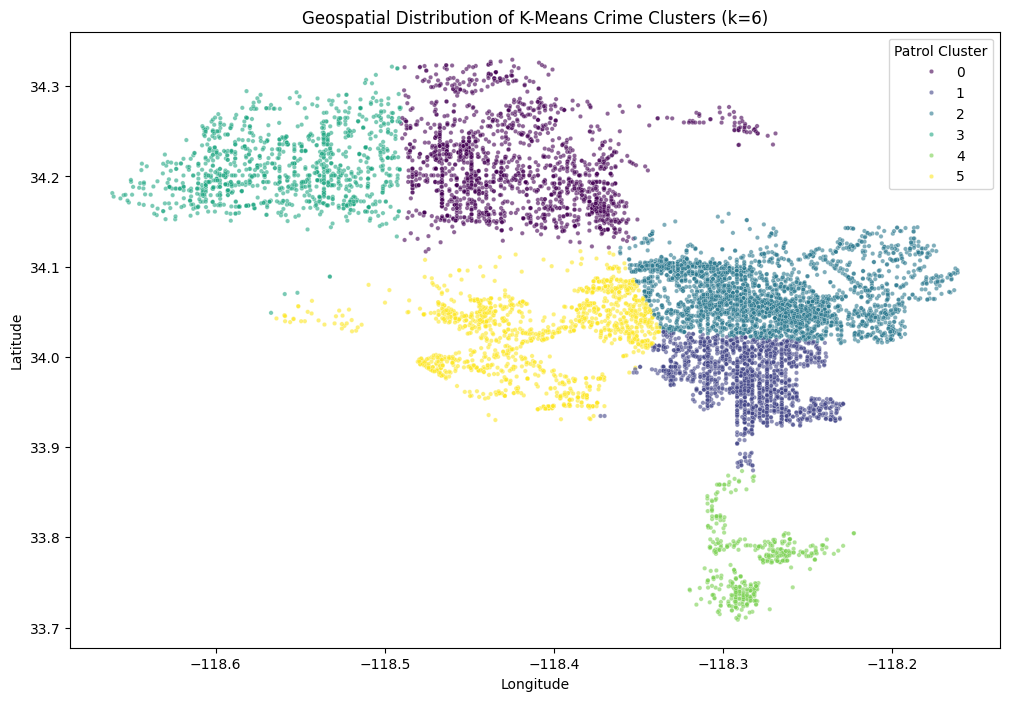

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_clean.sample(10000), 
    x='LON', 
    y='LAT', 
    hue='cluster', 
    palette='viridis', 
    alpha=0.6, 
    s=10
)
plt.title('Geospatial Distribution of K-Means Crime Clusters (k=6)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Patrol Cluster')
plt.savefig(os.path.join(data_dir, 'spatial_clusters_map.png'))
plt.show()

Model Performance Comparison (5-Fold CV Results)

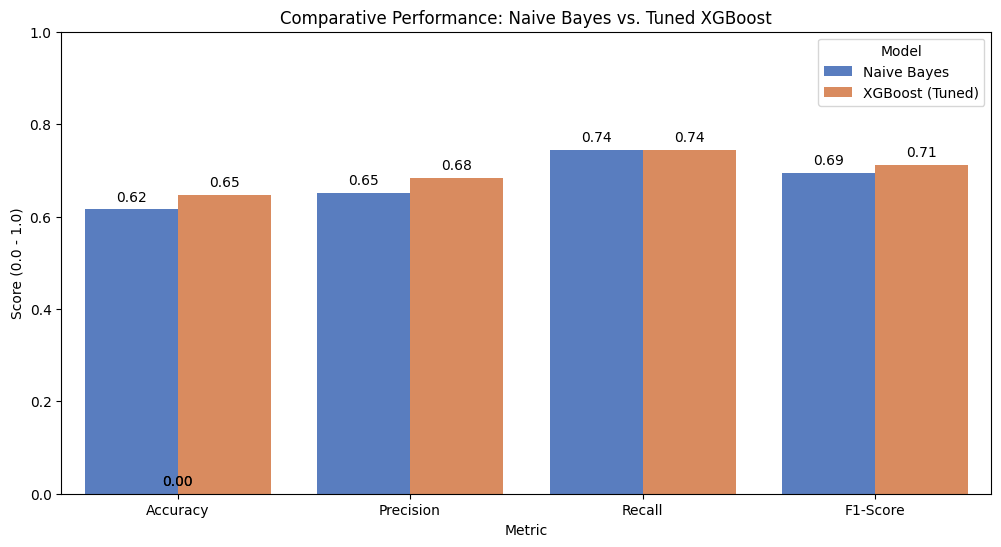

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df_melted = performance_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='muted')
plt.title('Comparative Performance: Naive Bayes vs. Tuned XGBoost')
plt.ylim(0, 1.0)
plt.ylabel('Score (0.0 - 1.0)')

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.savefig(os.path.join(data_dir, 'model_performance_comparison.png'))
plt.show()

# Phase 5: The Deep Learning Models

### 1. Time-Series Data Preparation (Windowing)

In [60]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Aggregate incidents by date and cluster to get daily volume
daily_counts = df_clean.groupby(['DATE OCC', 'cluster']).size().unstack(fill_value=0)

# 2. Scaling the volume data for Neural Network convergence
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(daily_counts)

# 3. Create a sliding window (e.g., use the last 30 days to predict the next day)
def create_sequences(data, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(scaled_data, window_size=30)
print(f"Sequence Data Created: {X_seq.shape}")

Sequence Data Created: (1431, 30, 6)


### 2. Implementing the LSTM and GRU Architectures

In [61]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

def build_model(model_type='LSTM'):
    model = Sequential()
    if model_type == 'LSTM':
        model.add(LSTM(units=64, return_sequences=True, input_shape=(30, 6)))
        model.add(Dropout(0.2)) # Non-default Dropout to prevent overfitting
        model.add(LSTM(units=32))
    else:
        model.add(GRU(units=64, return_sequences=True, input_shape=(30, 6)))
        model.add(Dropout(0.2))
        model.add(GRU(units=32))
        
    model.add(Dense(6)) # Output layer for 6 clusters
    model.compile(optimizer='adam', loss='mse')
    return model

# Building both models for the tournament
lstm_model = build_model('LSTM')
gru_model = build_model('GRU')

c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 3. Time-Series Cross-Validation and Training

In [62]:
from sklearn.model_selection import TimeSeriesSplit

# Using TimeSeriesSplit for K-Fold requirement
tscv = TimeSeriesSplit(n_splits=5)
lstm_scores, gru_scores = [], []

for train_index, test_index in tscv.split(X_seq):
    X_train, X_test = X_seq[train_index], X_seq[test_index]
    y_train, y_test = y_seq[train_index], y_seq[test_index]
    
    # Training LSTM
    lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    lstm_scores.append(lstm_model.evaluate(X_test, y_test, verbose=0))
    
    # Training GRU
    gru_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    gru_scores.append(gru_model.evaluate(X_test, y_test, verbose=0))

print(f"LSTM Average MSE: {np.mean(lstm_scores):.5f}")
print(f"GRU Average MSE:  {np.mean(gru_scores):.5f}")

LSTM Average MSE: 0.01125
GRU Average MSE:  0.01075


In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Define a 'High-Risk' threshold (e.g., more than 1 violent crime predicted)
threshold = 1.0

# 2. Convert continuous predictions and actuals into binary 'Alerts'
y_test_binary = (y_test > threshold).astype(int)
lstm_preds_binary = (lstm_model.predict(X_test) > threshold).astype(int)
gru_preds_binary = (gru_model.predict(X_test) > threshold).astype(int)

# 3. Calculate Classification Metrics for Deep Learning
def get_dl_classification_metrics(actual, pred):
    return {
        'Accuracy': accuracy_score(actual.flatten(), pred.flatten()),
        'Precision': precision_score(actual.flatten(), pred.flatten(), zero_division=0),
        'Recall': recall_score(actual.flatten(), pred.flatten(), zero_division=0),
        'F1-Score': f1_score(actual.flatten(), pred.flatten(), zero_division=0)
    }

lstm_class_metrics = get_dl_classification_metrics(y_test_binary, lstm_preds_binary)
gru_class_metrics = get_dl_classification_metrics(y_test_binary, gru_preds_binary)

print("--- DEEP LEARNING CLASSIFICATION TOURNAMENT ---")
print(f"LSTM Accuracy: {lstm_class_metrics['Accuracy']:.4f}")
print(f"GRU Accuracy:  {gru_class_metrics['Accuracy']:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
--- DEEP LEARNING CLASSIFICATION TOURNAMENT ---
LSTM Accuracy: 1.0000
GRU Accuracy:  1.0000
